In [63]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib
from matplotlib.collections import LineCollection

matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
# plt.style.use('dark_background')

import pickle, gzip
import torch
from torch_geometric.data import Data
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import scatter

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

from scipy.spatial import cKDTree

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [3]:
with gzip.open('graph_fid_0.pkl.gz', 'rb') as f:
    G = pickle.load(f)

N = G.number_of_nodes()
E = G.number_of_edges()

x = torch.tensor([[G.nodes[i]['PVOID'],
                   G.nodes[i]['PSHEET'],
                   G.nodes[i]['PFILAMENT'],
                   G.nodes[i]['PKNOT']] for i in range(N)], dtype=torch.float32)

pos = torch.tensor(np.array([G.nodes[i]['pos'] for i in range(N)]), dtype=torch.float32)

node_type = torch.tensor([0 if G.nodes[i]['node_type'] == 'halo' else 1 for i in range(N)], dtype=torch.long)

edges = np.array(list(G.edges()), dtype=np.int64)
edge_index = torch.tensor(edges.T, dtype=torch.long)
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

edge_distance = torch.tensor([data['distance'] for _, _, data in G.edges(data=True)], dtype=torch.float32)
edge_distance = torch.cat([edge_distance, edge_distance])
edge_attr = edge_distance[:, None]

edge_type_map = {'HH': 0, 'RR': 1}

edge_type = torch.tensor([edge_type_map[data['edge_type']] for _, _, data in G.edges(data=True)], dtype=torch.long)
edge_type = torch.cat([edge_type, edge_type])

data = Data(x=x, pos=pos, edge_index=edge_index, edge_attr=edge_attr)
data.node_type = node_type
data.edge_type = edge_type

data.halo_mask = node_type == 0
data.random_mask = node_type == 1

In [4]:
with open('delta_dm_randoms_R10.pkl', 'rb') as f:
    delta_dm_rand = pickle.load(f)

delta_dm_rand = torch.as_tensor(delta_dm_rand, dtype=torch.float32)
data.y = torch.full((N,), float('nan'), dtype=torch.float32)
data.y[data.random_mask] = delta_dm_rand

----

In [6]:
src = data.edge_index[0].cpu().numpy()
dst = data.edge_index[1].cpu().numpy()

dist = data.edge_attr[:, 0].cpu().numpy()
etype = data.edge_type.cpu().numpy()

In [7]:
rr = etype == 1

src_rr = src[rr]
dst_rr = dst[rr]
dist_rr = dist[rr]
len(src_rr)

1260414

In [10]:
df_edges = pd.DataFrame({'node': src_rr, 'distance': dist_rr})

features = df_edges.groupby('node')['distance'].agg(degree='count', d_mean='mean', d_std='std',
                                                    d_min='min', d_max='max', d_median='median')

In [11]:
random_ids = torch.where(data.random_mask)[0].cpu().numpy()

In [12]:
features = features.reindex(random_ids)
features.head()

,degree,d_mean,d_std,d_min,d_max,d_median
node,,,,,,
309740,11,16.618122,5.208853,9.788135,26.325792,18.555536
309741,9,13.608976,4.532028,6.076173,20.877272,14.939301
309742,12,16.549671,7.690912,7.520277,28.754129,16.328922
309743,9,17.219509,4.760416,11.326652,27.981804,16.699957
309744,8,17.370466,3.334504,12.189714,20.495453,17.952061


In [13]:
features.isna().sum()

degree      0
d_mean      0
d_std       0
d_min       0
d_max       0
d_median    0
dtype: int64

In [14]:
X = features.to_numpy(dtype=np.float32)
y = data.y[data.random_mask].cpu().numpy()
X.shape, y.shape

((130670, 6), (130670,))

In [15]:
rho_local = (features['degree'].to_numpy() /
             ((4.0 / 3.0) * np.pi * features['d_max'].to_numpy()**3))

X = np.column_stack([X, rho_local])

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [17]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

r, _ = pearsonr(y_test, y_pred)

print('RMSE      :', rmse)
print('R2        :', r2)
print('Pearson r :', r)

RMSE      : 0.15718770156759845
R2        : 0.14654833413348345
Pearson r : 0.38890459878234057


In [24]:
y_mean = np.full_like(y_test, y_train.mean())
rmse_mean = np.sqrt(mean_squared_error(y_test, y_mean))

print('RMSE mean :', rmse_mean)
print('RMSE RF   :', rmse)

RMSE mean : 0.17014975996925336
RMSE RF   : 0.15718770156759845


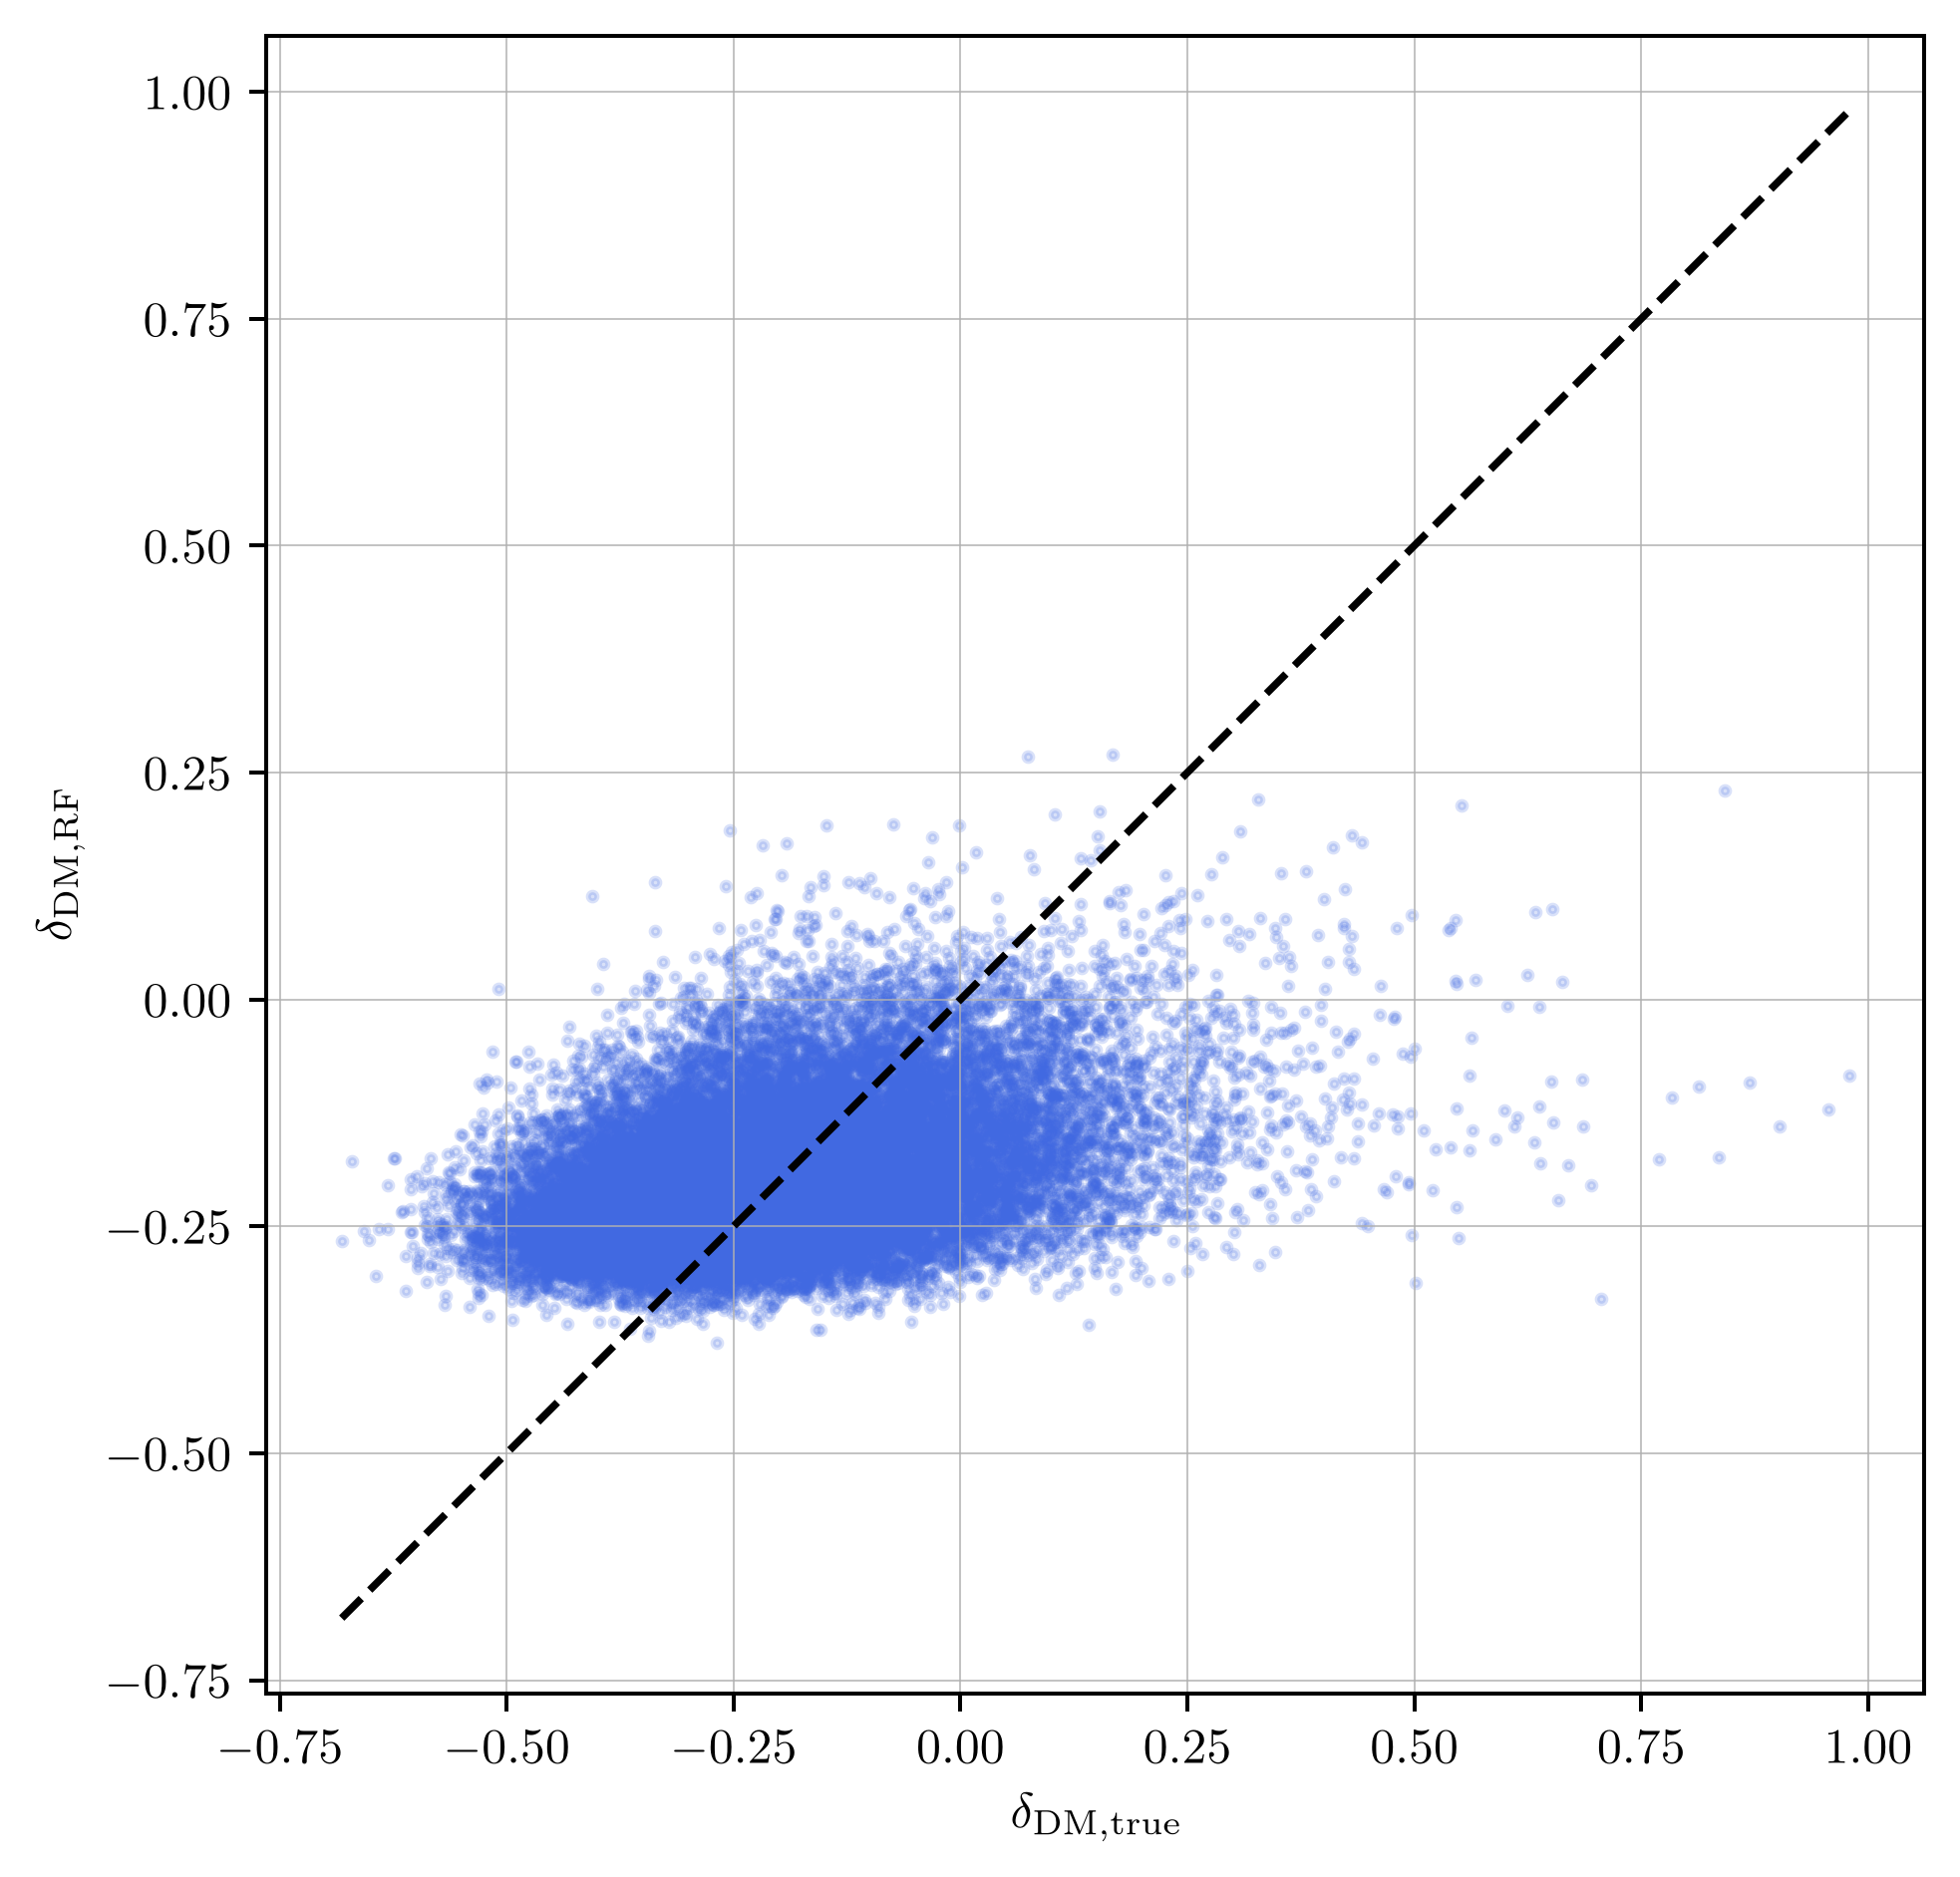

In [52]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.grid(lw=0.3)

ax.scatter(y_test,y_pred, s=3, alpha=0.2, c='royalblue')

lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())

ax.plot([lo, hi], [lo, hi], '--', c='black')

ax.set_xlabel(r'$\delta_{\rm DM,true}$')
ax.set_ylabel(r'$\delta_{\rm DM,RF}$')
ax.set_aspect('equal')
plt.show()

In [30]:
feature_names = ['degree', 'd_mean', 'd_std',
                                'd_min', 'd_max', 'd_median',
                                'rho_local']

importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
importance

d_mean       0.278827
d_median     0.149408
d_max        0.148050
d_std        0.142301
d_min        0.140947
rho_local    0.078626
degree       0.061841
dtype: float64

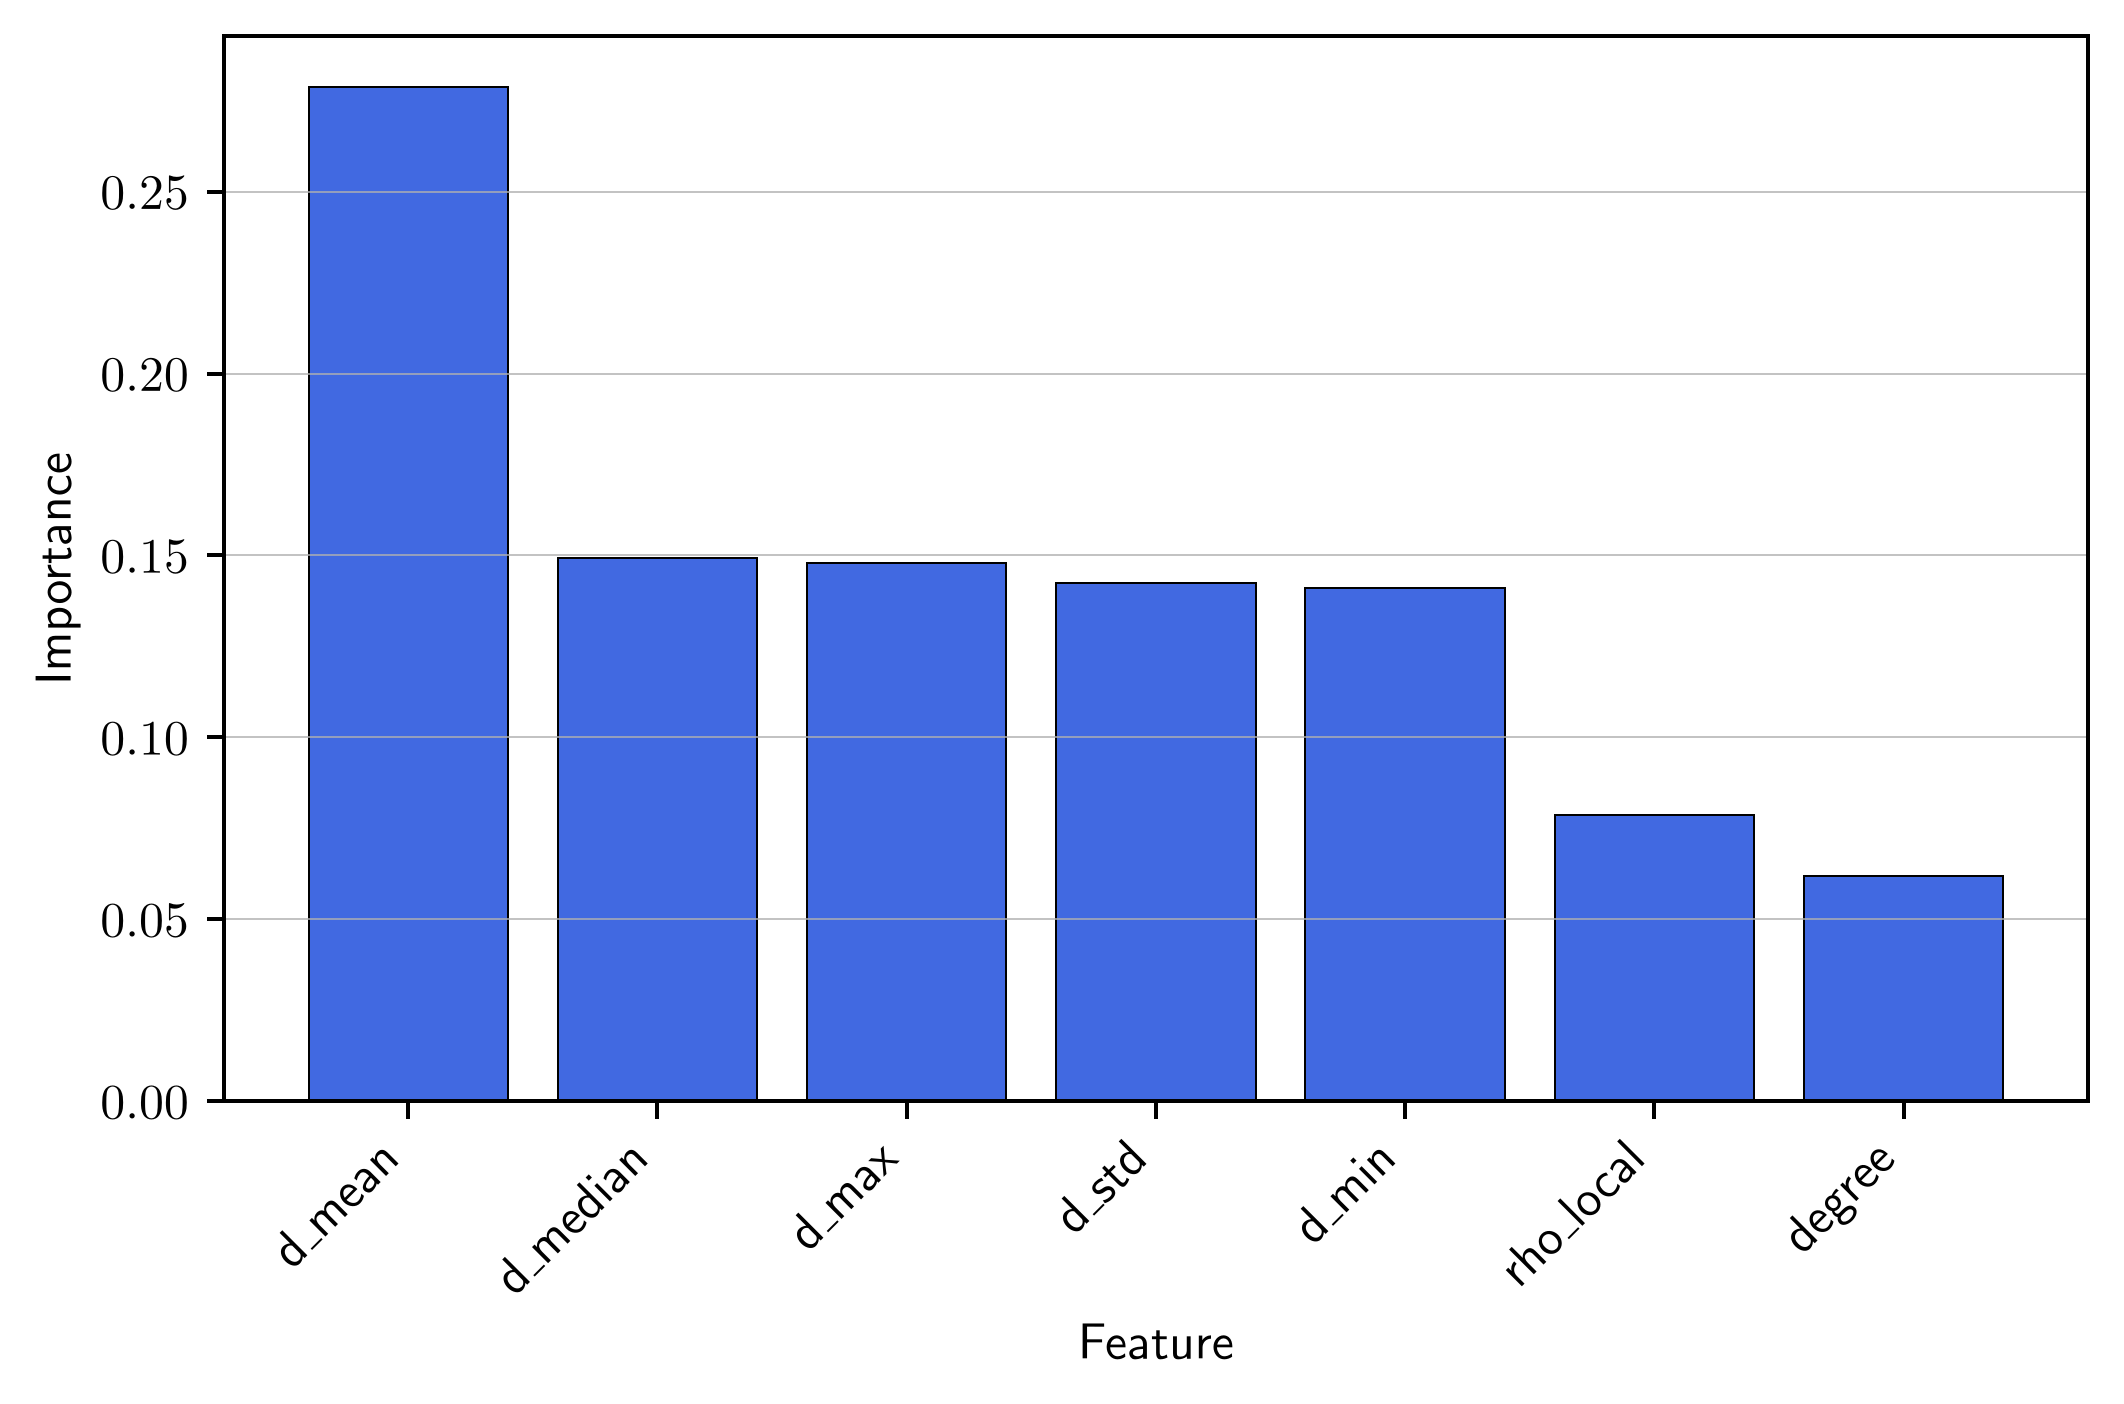

In [41]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.grid(lw=0.3, axis='y')

x = np.arange(len(importance))

ax.bar(x, importance.values, color='royalblue', lw=0.4, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(importance.index, rotation=45, ha='right')
ax.set_xlabel('Feature')
ax.set_ylabel('Importance')

plt.tight_layout()
plt.show()

----

In [46]:
lin = make_pipeline(StandardScaler(), LinearRegression())

lin.fit(X_train, y_train)
y_pred_lin = lin.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)
r_lin, _ = pearsonr(y_test, y_pred_lin)

print('RMSE      :', rmse_lin)
print('R2        :', r2_lin)
print('Pearson r :', r_lin)

RMSE      : 0.15526665999459197
R2        : 0.16728147784448633
Pearson r : 0.4090209567431363


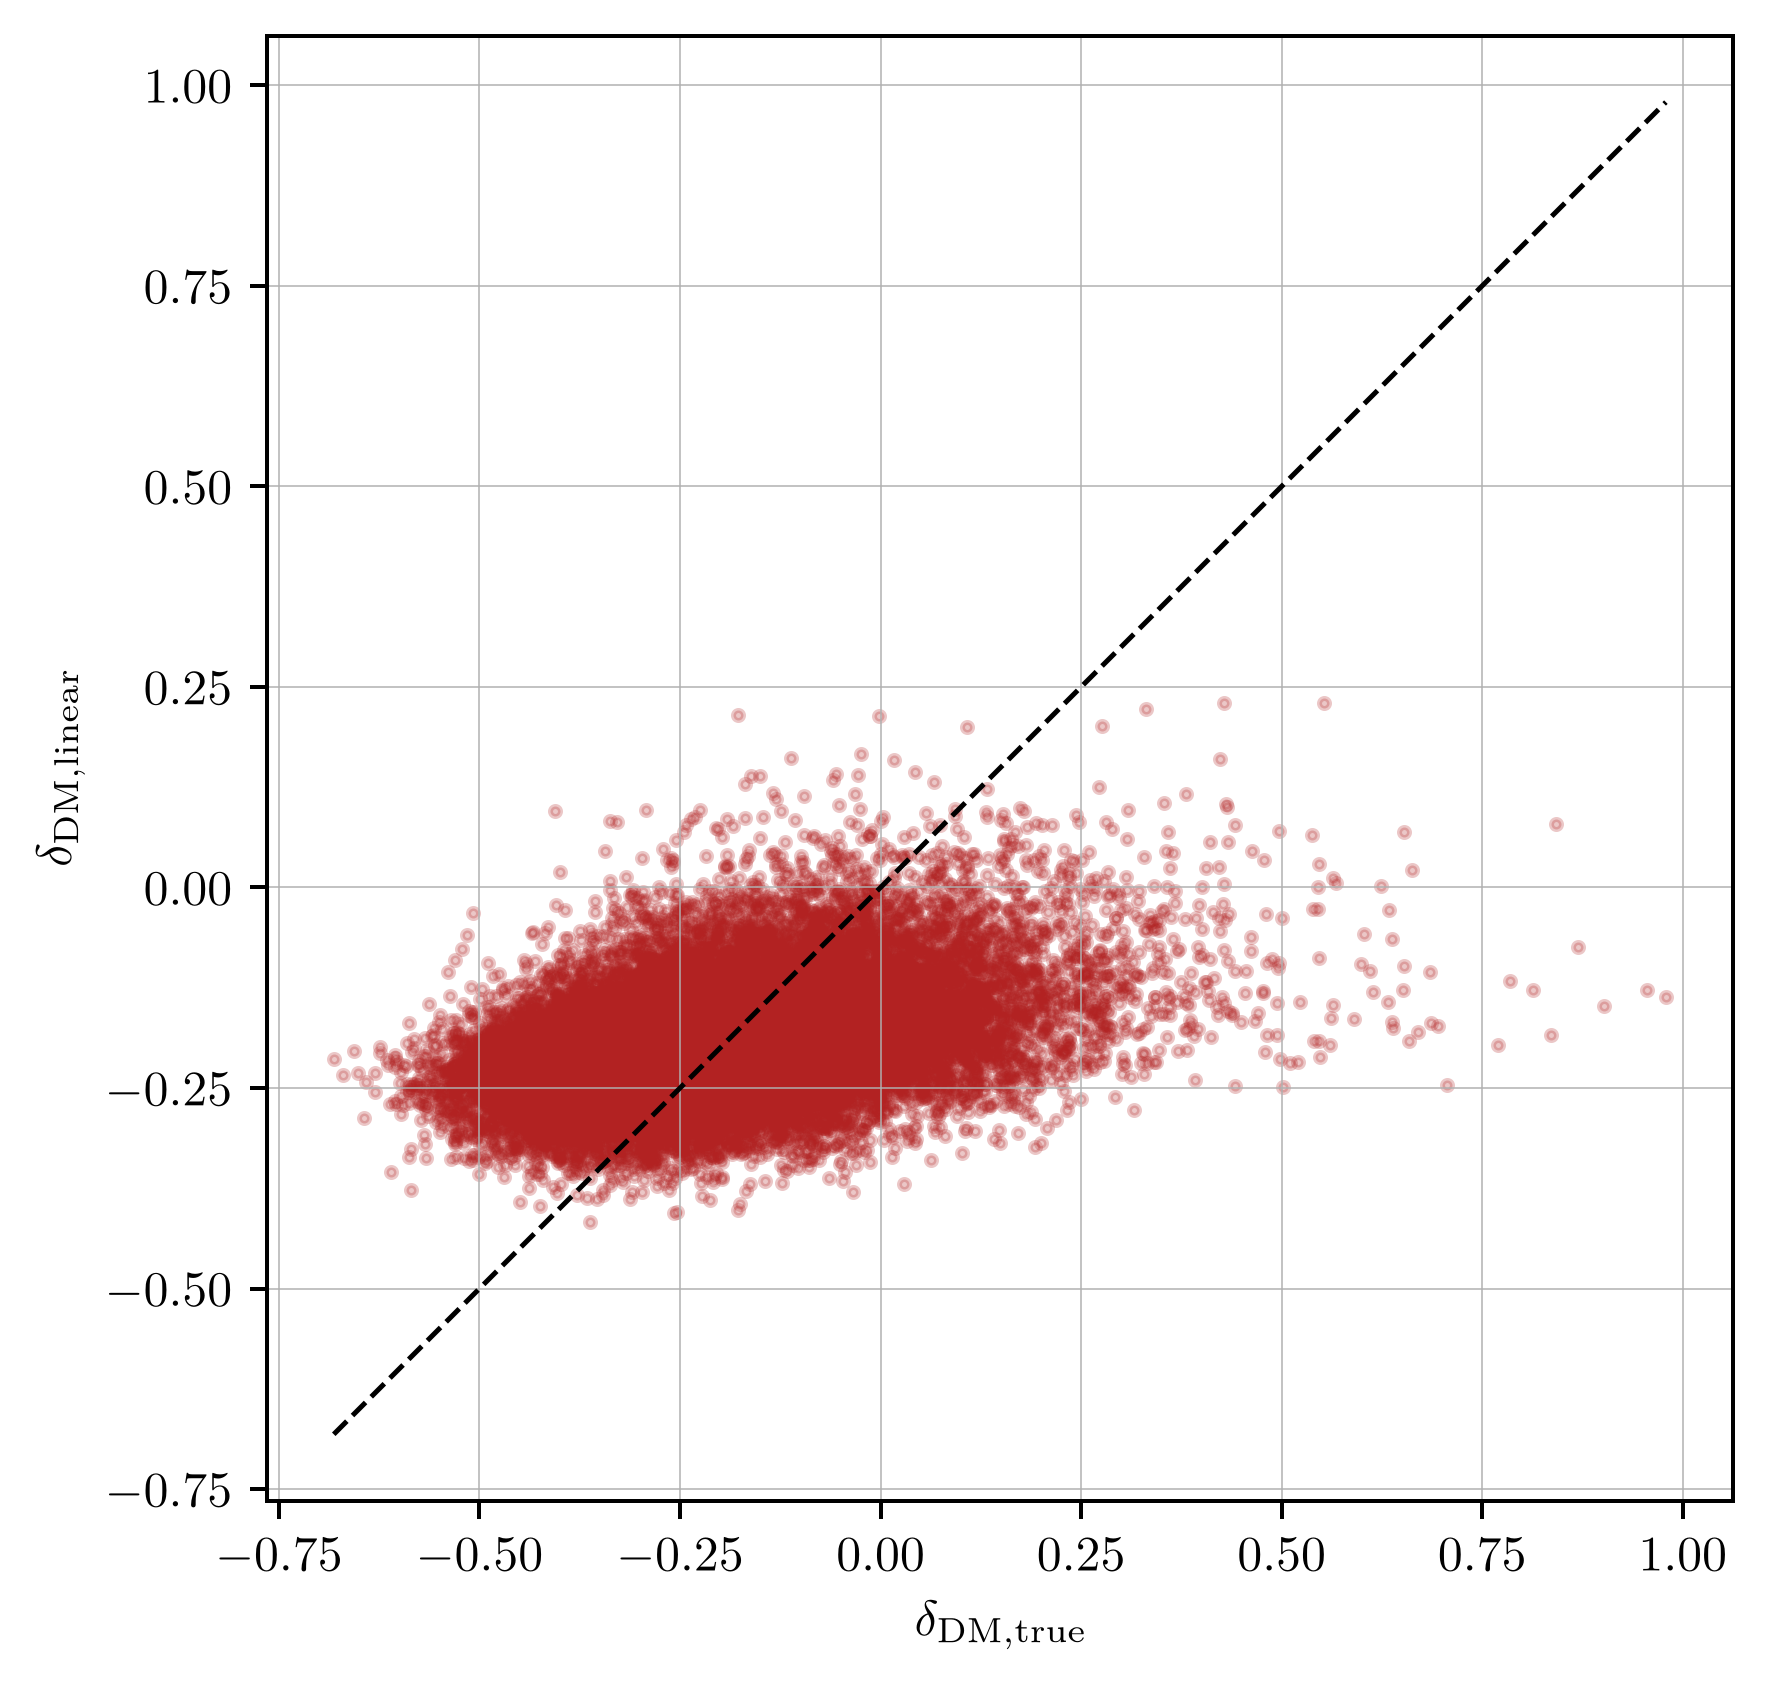

In [53]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.grid(lw=0.3)

ax.scatter(y_test, y_pred_lin, s=4, alpha=0.25, c='firebrick')

lo = min(y_test.min(), y_pred_lin.min())
hi = max(y_test.max(), y_pred_lin.max())

ax.plot([lo, hi], [lo, hi], '--', color='black', lw=1)

ax.set_xlabel(r'$\delta_{\rm DM,true}$')
ax.set_ylabel(r'$\delta_{\rm DM,linear}$')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

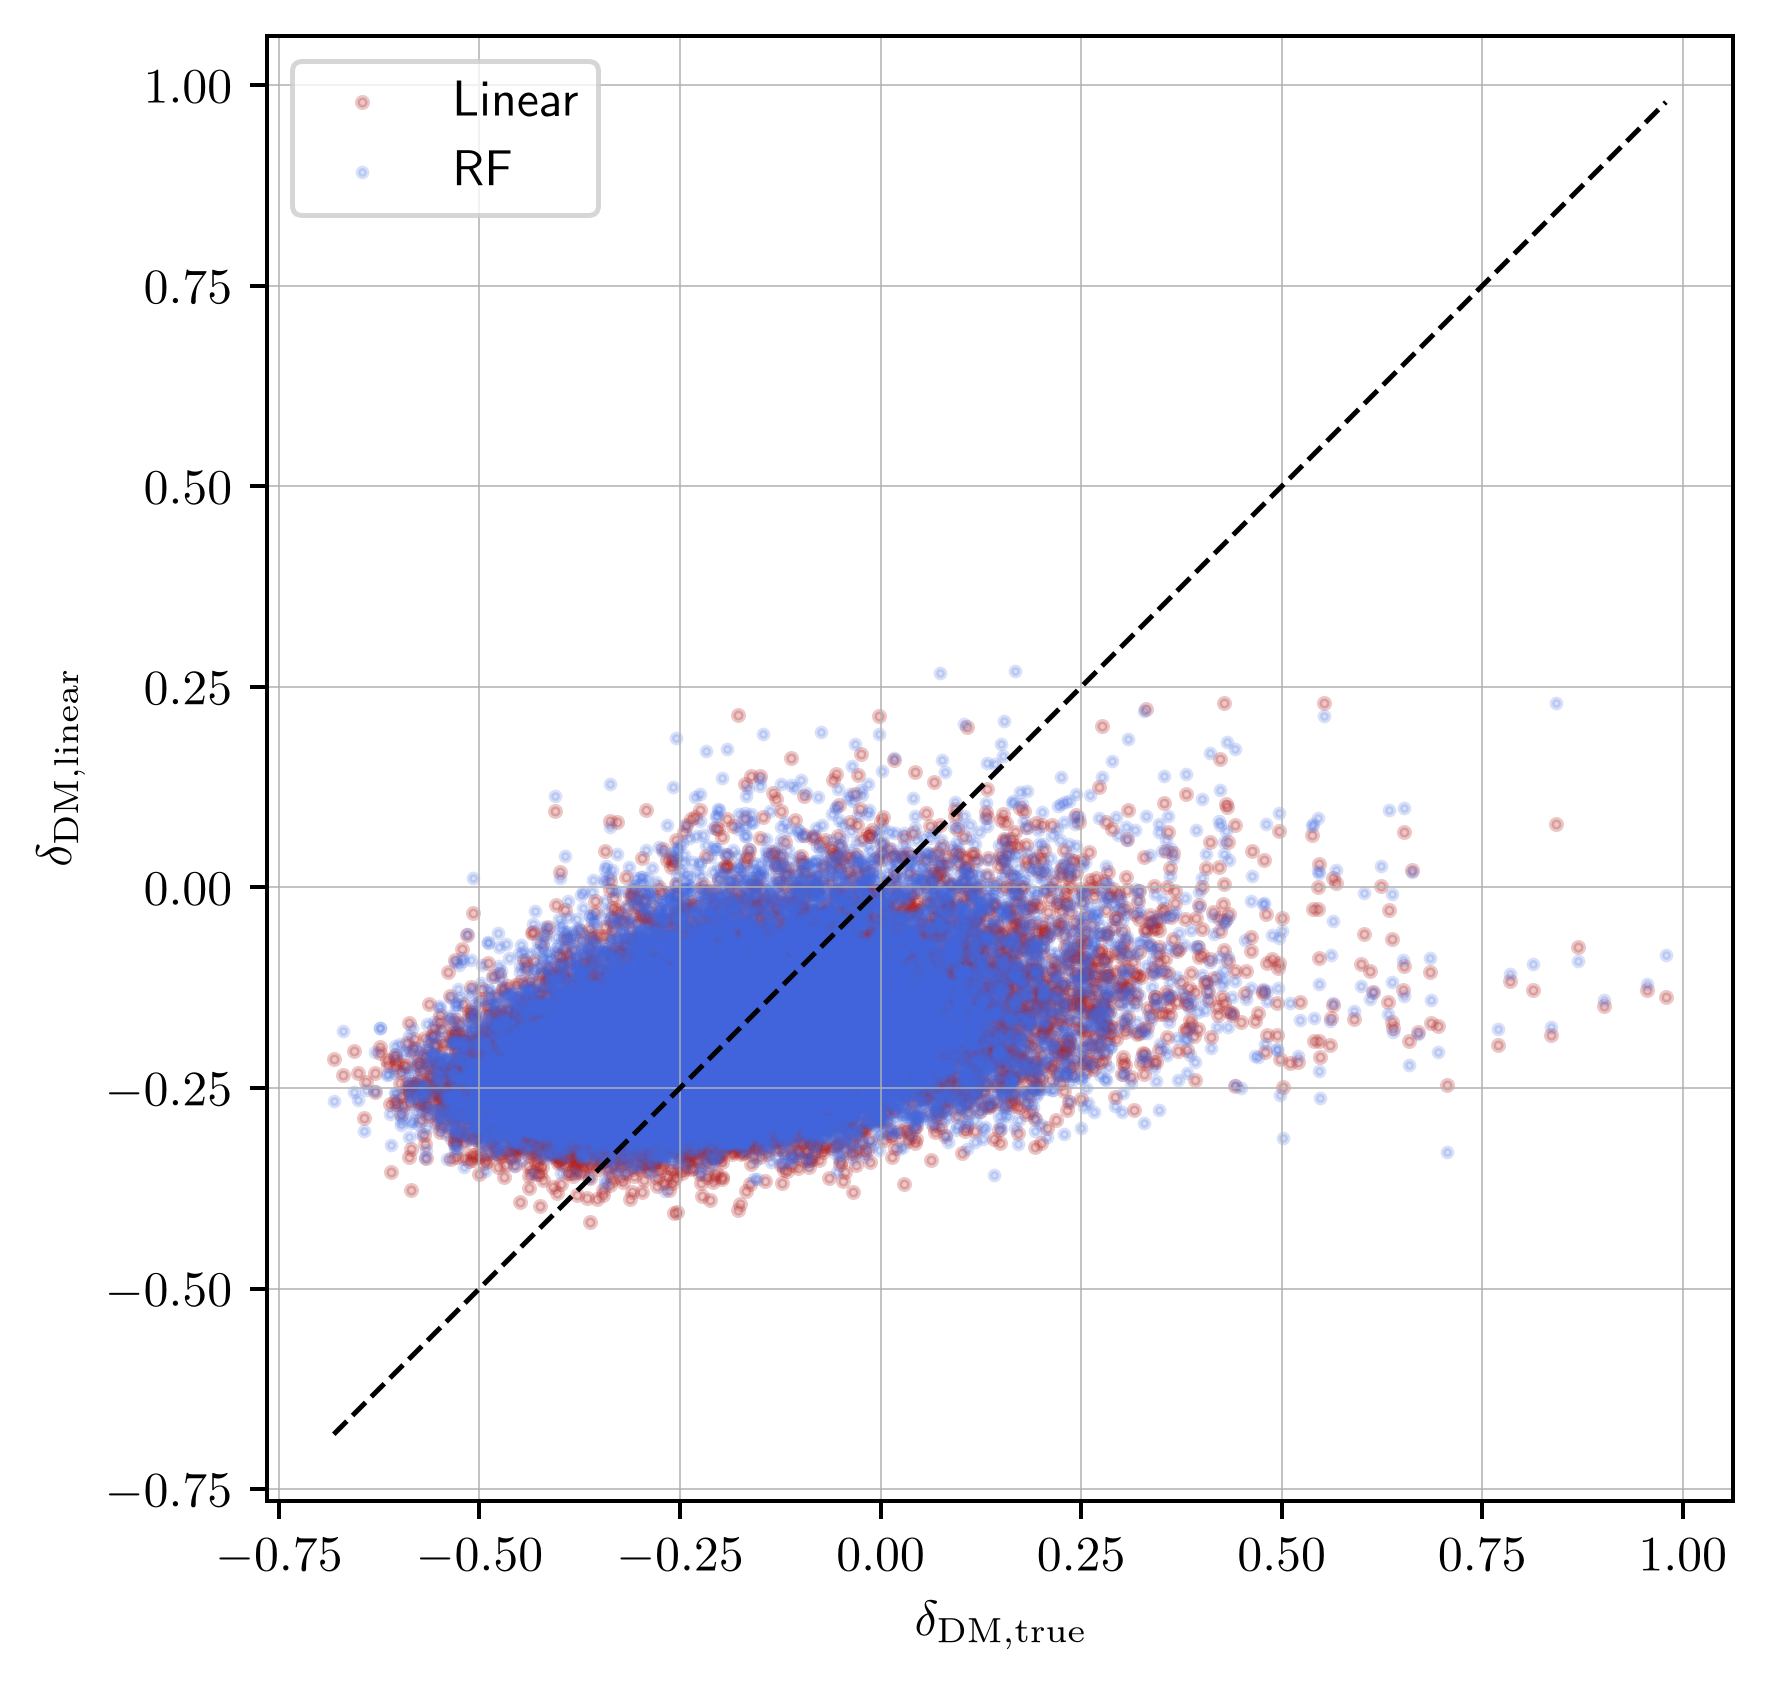

In [54]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.grid(lw=0.3)

ax.scatter(y_test, y_pred_lin, s=4, alpha=0.25, c='firebrick', label='Linear')
ax.scatter(y_test,y_pred, s=3, alpha=0.2, c='royalblue', label='RF')

lo = min(y_test.min(), y_pred_lin.min())
hi = max(y_test.max(), y_pred_lin.max())

ax.plot([lo, hi], [lo, hi], '--', color='black', lw=1)

ax.set_xlabel(r'$\delta_{\rm DM,true}$')
ax.set_ylabel(r'$\delta_{\rm DM,linear}$')
ax.set_aspect('equal')
plt.tight_layout()
plt.legend(loc='upper left')
plt.show()

In [51]:
print('Linear RMSE :', rmse_lin)
print('RF RMSE     :', rmse)

print('Linear R2   :', r2_lin)
print('RF R2       :', r2)

print('Linear r    :', r_lin)
print('RF r        :', r)

Linear RMSE : 0.15526665999459197
RF RMSE     : 0.15718770156759845
Linear R2   : 0.16728147784448633
RF R2       : 0.14654833413348345
Linear r    : 0.4090209567431363
RF r        : 0.38890459878234057
